In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv(r"C:\Users\Dell\Downloads\1768301836352-ML Project - Naive Bayes Loan Status Classification U16955482770.txt")

In [5]:
data

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Status
0,1,2.0,24,3913.0,312.0,689.0,NaN,NaN,NaN,NaN,689.0,NaN,NaN,NaN,NaN,Default
1,2,12.0,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,NaN,1.0,1.0,1.0,NaN,2.0,Default
2,3,9.0,34,29239.0,1427.0,13559.0,14331.0,14948.0,15549.0,1518.0,15.0,1.0,1.0,1.0,5.0,Not Default
3,4,5.0,37,4699.0,48233.0,49291.0,28314.0,28959.0,29547.0,2.0,219.0,12.0,11.0,169.0,1.0,Not Default
4,5,5.0,57,8617.0,567.0,35835.0,294.0,19146.0,19131.0,2.0,36681.0,1.0,9.0,689.0,679.0,Not Default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,22.0,39,188948.0,192815.0,28365.0,884.0,31237.0,1598.0,85.0,2.0,53.0,347.0,5.0,1.0,Not Default
29996,29997,15.0,43,1683.0,1828.0,352.0,8979.0,519.0,NaN,1837.0,3526.0,8998.0,129.0,NaN,NaN,Not Default
29997,29998,3.0,37,3565.0,3356.0,2758.0,2878.0,2582.0,19357.0,NaN,NaN,22.0,42.0,2.0,31.0,Default
29998,29999,8.0,41,-1645.0,78379.0,7634.0,52774.0,11855.0,48944.0,859.0,349.0,1178.0,1926.0,52964.0,184.0,Default


In [6]:
data.isnull().any()

ID                False
LIMIT_BAL         False
AGE               False
BILL_AMT1          True
BILL_AMT2          True
BILL_AMT3          True
BILL_AMT4          True
BILL_AMT5          True
BILL_AMT6          True
PAY_AMT1           True
PAY_AMT2           True
PAY_AMT3           True
PAY_AMT4           True
PAY_AMT5           True
PAY_AMT6           True
Default Status    False
dtype: bool

In [7]:
for col in data.columns:
    if data[col].dtype != "object":
        data[col].fillna(data[col].mean(), inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_14980\2939073370.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


In [8]:
data

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Status
0,1,2.0,24,3913.0,312.0,689.0,30709.50416,29015.123424,28526.276559,2613.957537,689.000000,2584.508988,2250.186122,2300.375885,2608.76576,Default
1,2,12.0,26,2682.0,1725.0,2682.0,3272.00000,3455.000000,3261.000000,2613.957537,1.000000,1.000000,1.000000,2300.375885,2.00000,Default
2,3,9.0,34,29239.0,1427.0,13559.0,14331.00000,14948.000000,15549.000000,1518.000000,15.000000,1.000000,1.000000,1.000000,5.00000,Not Default
3,4,5.0,37,4699.0,48233.0,49291.0,28314.00000,28959.000000,29547.000000,2.000000,219.000000,12.000000,11.000000,169.000000,1.00000,Not Default
4,5,5.0,57,8617.0,567.0,35835.0,294.00000,19146.000000,19131.000000,2.000000,36681.000000,1.000000,9.000000,689.000000,679.00000,Not Default
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,22.0,39,188948.0,192815.0,28365.0,884.00000,31237.000000,1598.000000,85.000000,2.000000,53.000000,347.000000,5.000000,1.00000,Not Default
29996,29997,15.0,43,1683.0,1828.0,352.0,8979.00000,519.000000,28526.276559,1837.000000,3526.000000,8998.000000,129.000000,2300.375885,2608.76576,Not Default
29997,29998,3.0,37,3565.0,3356.0,2758.0,2878.00000,2582.000000,19357.000000,2613.957537,2922.761583,22.000000,42.000000,2.000000,31.00000,Default
29998,29999,8.0,41,-1645.0,78379.0,7634.0,52774.00000,11855.000000,48944.000000,859.000000,349.000000,1178.000000,1926.000000,52964.000000,184.00000,Default


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              30000 non-null  int64  
 1   LIMIT_BAL       30000 non-null  float64
 2   AGE             30000 non-null  int64  
 3   BILL_AMT1       30000 non-null  float64
 4   BILL_AMT2       30000 non-null  float64
 5   BILL_AMT3       30000 non-null  float64
 6   BILL_AMT4       30000 non-null  float64
 7   BILL_AMT5       30000 non-null  float64
 8   BILL_AMT6       30000 non-null  float64
 9   PAY_AMT1        30000 non-null  float64
 10  PAY_AMT2        30000 non-null  float64
 11  PAY_AMT3        30000 non-null  float64
 12  PAY_AMT4        30000 non-null  float64
 13  PAY_AMT5        30000 non-null  float64
 14  PAY_AMT6        30000 non-null  float64
 15  Default Status  30000 non-null  object 
dtypes: float64(13), int64(2), object(1)
memory usage: 3.7+ MB


In [10]:
data.describe()

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,10666.660700,14.648867,32.427900,33989.494570,33938.750418,32617.867011,30709.50416,29015.123424,28526.276559,2613.957537,2.922762e+03,2584.508988,2250.186122,2300.375885,2608.765760
std,9698.091793,189.496507,12.718991,59472.881131,58305.224138,55777.906879,51825.29715,48612.594594,48042.412239,11398.052166,1.675277e+04,10956.873040,9805.177073,9756.444917,11652.208534
min,1.000000,1.000000,3.000000,-154973.000000,-69777.000000,-157264.000000,-81334.00000,-81334.000000,-94625.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000
25%,1850.500000,4.000000,26.000000,1788.000000,1847.750000,1862.000000,1782.00000,1718.000000,1724.000000,21.000000,1.900000e+01,15.000000,13.000000,13.000000,15.000000
50%,7483.500000,9.000000,33.000000,11569.000000,12637.000000,13255.000000,13350.00000,12847.000000,13398.500000,512.000000,5.150000e+02,431.000000,367.000000,387.000000,478.000000
75%,18746.250000,21.000000,41.000000,33989.494570,33938.750418,32617.867011,30709.50416,29015.123424,28526.276559,2613.957537,2.922762e+03,2584.508988,2250.186122,2300.375885,2608.765760
max,29999.000000,32768.000000,79.000000,964511.000000,983931.000000,693131.000000,891586.00000,927171.000000,961664.000000,873552.000000,1.684259e+06,417588.000000,528897.000000,426529.000000,528666.000000


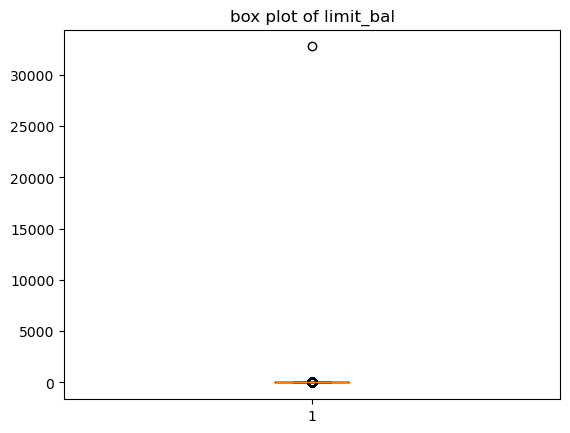

In [11]:
plt.boxplot(x="LIMIT_BAL",data=data)
plt.title("box plot of limit_bal")
plt.show()

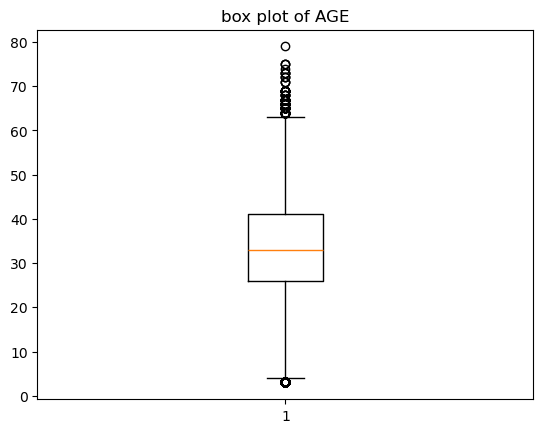

In [12]:
plt.boxplot(x="AGE",data=data)
plt.title("box plot of AGE")
plt.show()

In [13]:
data.dropna(inplace=True)

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
le=LabelEncoder()

In [16]:
data["Default Status"]=le.fit_transform(data["Default Status"])

In [17]:
data

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Status
0,1,2.0,24,3913.0,312.0,689.0,30709.50416,29015.123424,28526.276559,2613.957537,689.000000,2584.508988,2250.186122,2300.375885,2608.76576,0
1,2,12.0,26,2682.0,1725.0,2682.0,3272.00000,3455.000000,3261.000000,2613.957537,1.000000,1.000000,1.000000,2300.375885,2.00000,0
2,3,9.0,34,29239.0,1427.0,13559.0,14331.00000,14948.000000,15549.000000,1518.000000,15.000000,1.000000,1.000000,1.000000,5.00000,1
3,4,5.0,37,4699.0,48233.0,49291.0,28314.00000,28959.000000,29547.000000,2.000000,219.000000,12.000000,11.000000,169.000000,1.00000,1
4,5,5.0,57,8617.0,567.0,35835.0,294.00000,19146.000000,19131.000000,2.000000,36681.000000,1.000000,9.000000,689.000000,679.00000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,22.0,39,188948.0,192815.0,28365.0,884.00000,31237.000000,1598.000000,85.000000,2.000000,53.000000,347.000000,5.000000,1.00000,1
29996,29997,15.0,43,1683.0,1828.0,352.0,8979.00000,519.000000,28526.276559,1837.000000,3526.000000,8998.000000,129.000000,2300.375885,2608.76576,1
29997,29998,3.0,37,3565.0,3356.0,2758.0,2878.00000,2582.000000,19357.000000,2613.957537,2922.761583,22.000000,42.000000,2.000000,31.00000,0
29998,29999,8.0,41,-1645.0,78379.0,7634.0,52774.00000,11855.000000,48944.000000,859.000000,349.000000,1178.000000,1926.000000,52964.000000,184.00000,0


In [18]:
x=data.drop("Default Status",axis=1)
y=data["Default Status"]

In [19]:
from sklearn.model_selection import train_test_split

In [118]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=45)

In [119]:
from sklearn.naive_bayes import GaussianNB

In [120]:
model=GaussianNB()

In [121]:
model.fit(x_train,y_train)

GaussianNB()

In [122]:
model.score(x_train,y_train)

0.7614285714285715

In [123]:
model.score(x_test,y_test)

0.764

In [69]:
ypri=model.predict(x_test)
ypri

array([0, 1, 0, ..., 0, 0, 0])

In [27]:
from sklearn.metrics import classification_report,confusion_matrix, precision_score,accuracy_score,recall_score

In [28]:
print(classification_report(y_test,ypri))

              precision    recall  f1-score   support

           0       0.13      0.02      0.03      1953
           1       0.78      0.97      0.87      7047

    accuracy                           0.76      9000
   macro avg       0.46      0.49      0.45      9000
weighted avg       0.64      0.76      0.68      9000



In [29]:
confusion_matrix(y_test,ypri)

array([[  31, 1922],
       [ 202, 6845]])

In [30]:
precision_score(y_test,ypri)

0.7807687920611384

In [31]:
accuracy_score(y_test,ypri)

0.764

In [32]:
recall_score(y_test,ypri)

0.9713353199943239